# Improved Random Forest Model for δ18O Prediction
This notebook implements several improvements over the basic random forest model:
- Proper data splitting with shuffling
- Feature engineering (temporal and additional features)
- Hyperparameter tuning
- Cross-validation
- Leave-One-Out Cross-Validation (LOOCV)
- Comprehensive model evaluation metrics
- Feature importance analysis
- Better visualization

In [58]:
%pip install scikit-learn pandas openpyxl matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load and Explore Data

In [60]:
# Load data
df = pd.read_excel("Random Forest Data.xlsx", header=1, usecols="B:L")

# Filter for stream data
stream = df[df["Rain or Stream"].str.lower().eq("stream")].copy()

print(f"Total stream samples: {len(stream)}")
print(f"\nData shape: {stream.shape}")
print(f"\nMissing values:\n{stream.isnull().sum()}")
print(f"\nBasic statistics:\n{stream.describe()}")

rs = 400


Total stream samples: 123

Data shape: (123, 11)

Missing values:
Date                      0
Site ID                   0
δ18O                      0
δ2H                       0
d-excess (‰)              0
Temperature               0
Discharge (m3/s)          0
% Groundwater Mixing    102
Rain or Stream            0
Elevation (ft)            0
Precipitation (mm)        0
dtype: int64

Basic statistics:
                             Date     Site ID        δ18O         δ2H  \
count                         123  123.000000  123.000000  123.000000   
mean   2023-12-26 08:09:50.731707    4.430894   -2.644715   -7.328455   
min           2023-02-13 09:35:00    1.000000   -8.400000  -58.300000   
25%           2023-05-15 10:31:30    3.000000   -2.600000   -6.300000   
50%           2023-08-15 11:25:00    5.000000   -2.400000   -4.700000   
75%           2023-12-06 10:52:00    6.000000   -2.300000   -3.650000   
max           2026-04-10 10:32:00    7.000000   -0.900000    2.100000   
std       

## 2. Feature Engineering
Create additional features that might improve model performance

In [61]:
# Extract temporal features from Date
stream['Month'] = stream['Date'].dt.month
stream['Day_of_Year'] = stream['Date'].dt.dayofyear
stream['Year'] = stream['Date'].dt.year
stream["DOY_sin"] = np.sin(2 * np.pi * stream['Day_of_Year'] / 365.25)
stream["DOY_cos"] = np.cos(2 * np.pi * stream['Day_of_Year'] / 365.25)
                          

# Create interaction features
stream['Temp_Discharge_Interaction'] = stream['Temperature '] * stream['Discharge (m3/s)']

# Add other isotope data as features (they're related to δ18O)
stream['d_excess'] = stream['d-excess (‰)']
stream['d2H'] = stream['δ2H']

# Rain Feature
stream['Rain'] = stream['Precipitation (mm)']
stream['Elevation'] = stream['Elevation (ft)']

# Define feature columns
feature_col = [
    "Site ID", 
    "Temperature ", 
    "Discharge (m3/s)",
    #"Month",
    #"Day_of_Year",
    #"d_excess",
   #"d2H",
   "DOY_sin",
   "DOY_cos",
    "Temp_Discharge_Interaction",
    "Rain",
    "Elevation"
]

print(f"Features used: {feature_col}")
print(f"\nFeature correlations with δ18O:")
correlations = stream[feature_col + ['δ18O']].corr()['δ18O'].sort_values(ascending=False)
print(correlations)

Features used: ['Site ID', 'Temperature ', 'Discharge (m3/s)', 'DOY_sin', 'DOY_cos', 'Temp_Discharge_Interaction', 'Rain', 'Elevation']

Feature correlations with δ18O:
δ18O                          1.000000
Temperature                   0.378645
Elevation                     0.017763
Site ID                      -0.001983
DOY_cos                      -0.179332
Rain                         -0.182973
DOY_sin                      -0.214551
Temp_Discharge_Interaction   -0.424358
Discharge (m3/s)             -0.429339
Name: δ18O, dtype: float64


## 3. Proper Data Splitting
Use train_test_split with shuffling for better generalization

In [62]:
# Prepare features and target
X = stream[feature_col]
y = stream["δ18O"]

# Split data with shuffling (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=rs, shuffle=True
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set δ18O range: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"Test set δ18O range: [{y_test.min():.2f}, {y_test.max():.2f}]")

Training set size: 98
Test set size: 25

Training set δ18O range: [-8.40, -0.90]
Test set δ18O range: [-5.90, -0.90]


## 4. Baseline Model (Default Parameters)

In [63]:
# Train baseline model
baseline_rf = RandomForestRegressor(random_state=rs)
baseline_rf.fit(X_train, y_train)

# Predictions
y_pred_baseline = baseline_rf.predict(X_test)

# Evaluate
baseline_r2 = r2_score(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)

print("Baseline Model Performance:")
print(f"R² Score: {baseline_r2:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"MAE: {baseline_mae:.4f}")

Baseline Model Performance:
R² Score: 0.7411
RMSE: 0.4608
MAE: 0.3344


## 5. Hyperparameter Tuning
Use GridSearchCV to find optimal parameters

In [64]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2']
}

# Perform grid search with cross-validation
print("Performing hyperparameter tuning... This may take a few minutes.")
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=rs),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation R² score: {grid_search.best_score_:.4f}")

Performing hyperparameter tuning... This may take a few minutes.
Fitting 5 folds for each of 384 candidates, totalling 1920 fits

Best parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validation R² score: 0.1853


## 6. Optimized Model Evaluation

In [65]:
# Get the best model
optimized_rf = grid_search.best_estimator_

# Predictions
y_pred_optimized = optimized_rf.predict(X_test)

# Evaluate
optimized_r2 = r2_score(y_test, y_pred_optimized)
optimized_rmse = np.sqrt(mean_squared_error(y_test, y_pred_optimized))
optimized_mae = mean_absolute_error(y_test, y_pred_optimized)

# Pearson correlation test for Test Set
test_pearson_r, test_pearson_p = pearsonr(y_test, y_pred_optimized)

print("Optimized Model Performance:")
print(f"R² Score: {optimized_r2:.4f}")
print(f"RMSE: {optimized_rmse:.4f}")
print(f"MAE: {optimized_mae:.4f}")
print(f"\n--- PEARSON CORRELATION TEST (Test Set) ---")
print(f"Pearson r: {test_pearson_r:.4f}")
print(f"P-value: {test_pearson_p:.4e}")
if test_pearson_p < 0.001:
    print(f"Significance: *** (p < 0.001) - Highly significant correlation")
elif test_pearson_p < 0.01:
    print(f"Significance: ** (p < 0.01) - Very significant correlation")
elif test_pearson_p < 0.05:
    print(f"Significance: * (p < 0.05) - Significant correlation")
else:
    print(f"Significance: Not significant (p >= 0.05)")


print(f"\nImprovement over baseline:")
print(f"R² improvement: {(optimized_r2 - baseline_r2):.4f} ({((optimized_r2 - baseline_r2)/baseline_r2)*100:.2f}%)")
print(f"RMSE improvement: {(baseline_rmse - optimized_rmse):.4f} ({((baseline_rmse - optimized_rmse)/baseline_rmse)*100:.2f}%)")

Optimized Model Performance:
R² Score: 0.6675
RMSE: 0.5222
MAE: 0.3871

--- PEARSON CORRELATION TEST (Test Set) ---
Pearson r: 0.9183
P-value: 9.8340e-11
Significance: *** (p < 0.001) - Highly significant correlation

Improvement over baseline:
R² improvement: -0.0736 (-9.93%)
RMSE improvement: -0.0614 (-13.33%)


## 7. Cross-Validation Analysis

In [66]:
# Perform cross-validation on the full dataset

from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_val_predict

tscv = TimeSeriesSplit(n_splits=3)

cv_scores = cross_val_score(optimized_rf, X, y, cv=tscv, scoring='r2')

print("Time Series Cross-Validation Results:")
print(f"R² scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Get cross-validated predictions for visualization
splits = list(tscv.split(X))
y_pred_cv = np.full(len(y), np.nan)

for train_idx, test_idx in splits:
    model_cv = RandomForestRegressor(**grid_search.best_params_, random_state=rs)
    model_cv.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred_cv[test_idx] = model_cv.predict(X.iloc[test_idx])

# Fill missing predictions (first block) using the first fold's training data
missing_mask = np.isnan(y_pred_cv)
if missing_mask.any():
    first_train_idx = splits[0][0]
    model_init = RandomForestRegressor(**grid_search.best_params_, random_state=rs)
    model_init.fit(X.iloc[first_train_idx], y.iloc[first_train_idx])
    y_pred_cv[missing_mask] = model_init.predict(X.iloc[missing_mask])

# Calculate overall metrics
cv_r2_overall = r2_score(y, y_pred_cv)
cv_rmse_overall = np.sqrt(mean_squared_error(y, y_pred_cv))
cv_mae_overall = mean_absolute_error(y, y_pred_cv)

print(f"\nOverall Cross-Validation Metrics:")
print(f"  R² Score: {cv_r2_overall:.4f}")
print(f"  RMSE: {cv_rmse_overall:.4f} ‰")
print(f"  MAE: {cv_mae_overall:.4f} ‰")

# Pearson correlation test for Time Series CV
cv_pearson_r, cv_pearson_p = pearsonr(y, y_pred_cv)

print(f"\n--- PEARSON CORRELATION TEST (Time Series CV) ---")
print(f"Pearson r: {cv_pearson_r:.4f}")
print(f"P-value: {cv_pearson_p:.4e}")
if cv_pearson_p < 0.001:
    print(f"Significance: *** (p < 0.001) - Highly significant correlation")
elif cv_pearson_p < 0.01:
    print(f"Significance: ** (p < 0.01) - Very significant correlation")
elif cv_pearson_p < 0.05:
    print(f"Significance: * (p < 0.05) - Significant correlation")
else:
    print(f"Significance: Not significant (p >= 0.05)")

Time Series Cross-Validation Results:
R² scores: [-2.10843085  0.19331758 -0.85956983]
Mean R²: -0.9249 (+/- 1.8816)

Overall Cross-Validation Metrics:
  R² Score: 0.1047
  RMSE: 1.0060 ‰
  MAE: 0.6550 ‰

--- PEARSON CORRELATION TEST (Time Series CV) ---
Pearson r: 0.4220
P-value: 1.1676e-06
Significance: *** (p < 0.001) - Highly significant correlation


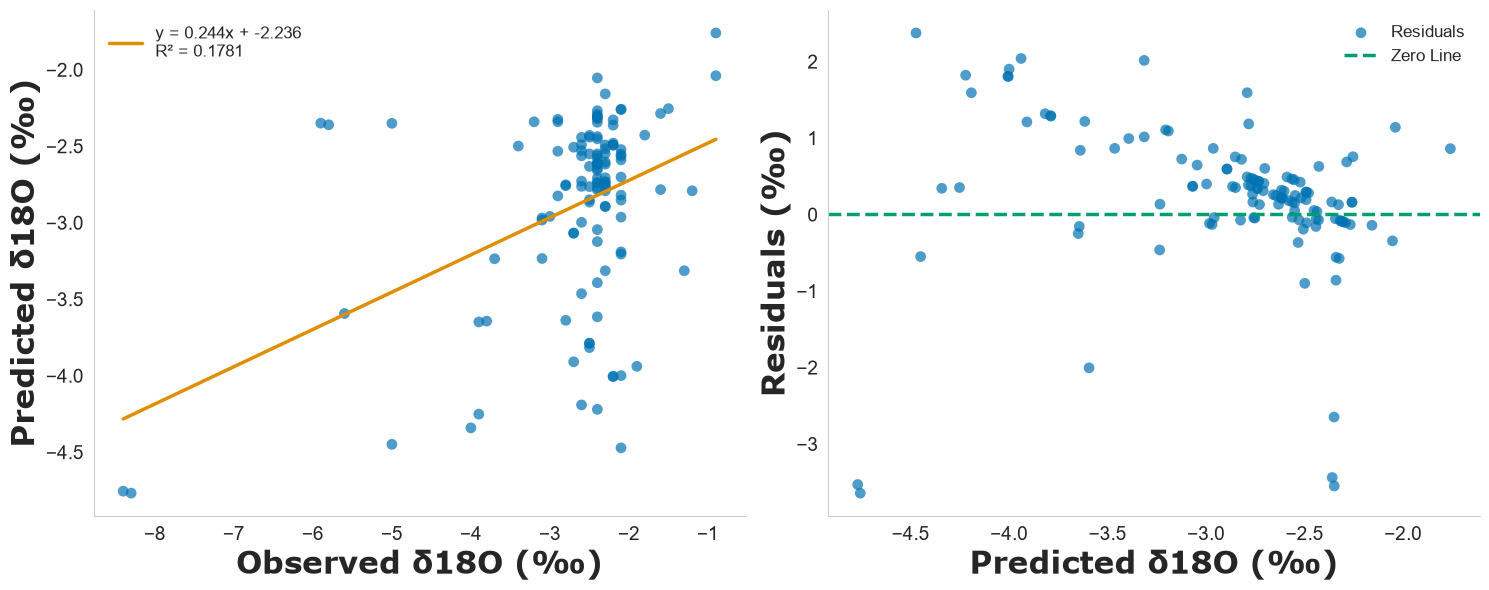


K-Fold CV Residual Statistics:
  Mean residual: 0.2356 ‰
  Std deviation: 0.9820 ‰
  Min residual: -3.6443 ‰
  Max residual: 2.3725 ‰
  Median absolute residual: 0.3684 ‰


In [67]:
# Visualize K-Fold Cross-Validation results
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Predicted vs Observed for K-Fold CV
axes[0].scatter(y, y_pred_cv, alpha=0.7, color='#0173B2', s=60, edgecolors='none')

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(y, y_pred_cv)
line_x = np.array([y.min(), y.max()])
line_y = slope * line_x + intercept
axes[0].plot(line_x, line_y, color='#DE8F05', linestyle='-', lw=2.5, 
             label=f'y = {slope:.3f}x + {intercept:.3f}\nR² = {r_value**2:.4f}')

axes[0].set_xlabel('Observed δ18O (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[0].set_ylabel('Predicted δ18O (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[0].tick_params(axis='both', which='major', labelsize=14)
axes[0].legend(fontsize=12, frameon=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(False)

# 2. Residuals plot for K-Fold CV
residuals_cv = y - y_pred_cv
axes[1].scatter(y_pred_cv, residuals_cv, alpha=0.7, color='#0173B2', s=60, edgecolors='none', label='Residuals')
axes[1].axhline(y=0, color='#029E73', linestyle='--', lw=2.5, label='Zero Line')
axes[1].set_xlabel('Predicted δ18O (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[1].set_ylabel('Residuals (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[1].tick_params(axis='both', which='major', labelsize=14)
axes[1].legend(fontsize=12, frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(False)

plt.tight_layout()
plt.show()

# Additional statistics
print("\nK-Fold CV Residual Statistics:")
print(f"  Mean residual: {residuals_cv.mean():.4f} ‰")
print(f"  Std deviation: {residuals_cv.std():.4f} ‰")
print(f"  Min residual: {residuals_cv.min():.4f} ‰")
print(f"  Max residual: {residuals_cv.max():.4f} ‰")
print(f"  Median absolute residual: {np.median(np.abs(residuals_cv)):.4f} ‰")

## 7.5. Leave-One-Out Cross-Validation (LOOCV)
LOOCV is an exhaustive cross-validation method where each sample is used once as a test set.
This provides an unbiased estimate of model performance but can be computationally expensive.

In [68]:
from sklearn.model_selection import LeaveOneOut
import time

# Initialize Leave-One-Out cross-validator
loo = LeaveOneOut()

print(f"Performing Leave-One-Out Cross-Validation on {len(X)} samples...")
print("This may take a few minutes depending on dataset size.\n")

# Track predictions and actual values
y_true_loocv = []
y_pred_loocv = []

# Start timing
start_time = time.time()

# Perform LOOCV
for i, (train_index, test_index) in enumerate(loo.split(X)):
    # Split data
    X_train_loo, X_test_loo = X.iloc[train_index], X.iloc[test_index]
    y_train_loo, y_test_loo = y.iloc[train_index], y.iloc[test_index]
    
    # Train model (using optimized parameters)
    model_loo = RandomForestRegressor(**grid_search.best_params_, random_state=50)
    model_loo.fit(X_train_loo, y_train_loo)
    
    # Predict
    y_pred = model_loo.predict(X_test_loo)
    
    # Store results
    y_true_loocv.append(y_test_loo.values[0])
    y_pred_loocv.append(y_pred[0])
    
    # Progress indicator (every 10 iterations)
    if (i + 1) % 10 == 0:
        print(f"Progress: {i + 1}/{len(X)} iterations completed")

# End timing
end_time = time.time()
elapsed_time = end_time - start_time

# Convert to numpy arrays
y_true_loocv = np.array(y_true_loocv)
y_pred_loocv = np.array(y_pred_loocv)

# Calculate metrics
loocv_r2 = r2_score(y_true_loocv, y_pred_loocv)
loocv_rmse = np.sqrt(mean_squared_error(y_true_loocv, y_pred_loocv))
loocv_mae = mean_absolute_error(y_true_loocv, y_pred_loocv)
# Pearson correlation test for LOOCV
loocv_pearson_r, loocv_pearson_p = pearsonr(y_true_loocv, y_pred_loocv)

print("\n" + "="*60)
print("LEAVE-ONE-OUT CROSS-VALIDATION RESULTS")
print("="*60)
print(f"Total iterations: {len(X)}")
print(f"Time elapsed: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
print(f"\nPerformance Metrics:")
print(f"  R² Score: {loocv_r2:.4f}")
print(f"  RMSE: {loocv_rmse:.4f} ‰")
print(f"  MAE: {loocv_mae:.4f} ‰")
print(f"\n--- PEARSON CORRELATION TEST (LOOCV) ---")
print(f"Pearson r: {loocv_pearson_r:.4f}")
print(f"P-value: {loocv_pearson_p:.4e}")
if loocv_pearson_p < 0.001:
    print(f"Significance: *** (p < 0.001) - Highly significant correlation")
elif loocv_pearson_p < 0.01:
    print(f"Significance: ** (p < 0.01) - Very significant correlation")
elif loocv_pearson_p < 0.05:
    print(f"Significance: * (p < 0.05) - Significant correlation")
else:
    print(f"Significance: Not significant (p >= 0.05)")
print("\nComparison with other validation methods:")
print(f"  K-Fold R² Score: {cv_r2_overall:.4f}")
print(f"  K-Fold MAE: {cv_mae_overall:.4f} ‰")
print(f"  LOOCV R²: {loocv_r2:.4f}")
print(f"  LOOCV MAE: {loocv_mae:.4f} ‰")
print(f"  Test Set R²: {optimized_r2:.4f}")
print(f"  Test Set MAE: {optimized_mae:.4f} ‰")
print("="*60) 

Performing Leave-One-Out Cross-Validation on 123 samples...
This may take a few minutes depending on dataset size.

Progress: 10/123 iterations completed
Progress: 20/123 iterations completed
Progress: 30/123 iterations completed
Progress: 40/123 iterations completed
Progress: 50/123 iterations completed
Progress: 60/123 iterations completed
Progress: 70/123 iterations completed
Progress: 80/123 iterations completed
Progress: 90/123 iterations completed
Progress: 100/123 iterations completed
Progress: 110/123 iterations completed
Progress: 120/123 iterations completed

LEAVE-ONE-OUT CROSS-VALIDATION RESULTS
Total iterations: 123
Time elapsed: 42.35 seconds (0.71 minutes)

Performance Metrics:
  R² Score: 0.4678
  RMSE: 0.7756 ‰
  MAE: 0.4265 ‰

--- PEARSON CORRELATION TEST (LOOCV) ---
Pearson r: 0.7050
P-value: 9.0134e-20
Significance: *** (p < 0.001) - Highly significant correlation

Comparison with other validation methods:
  K-Fold R² Score: 0.1047
  K-Fold MAE: 0.6550 ‰
  LOOCV R²:

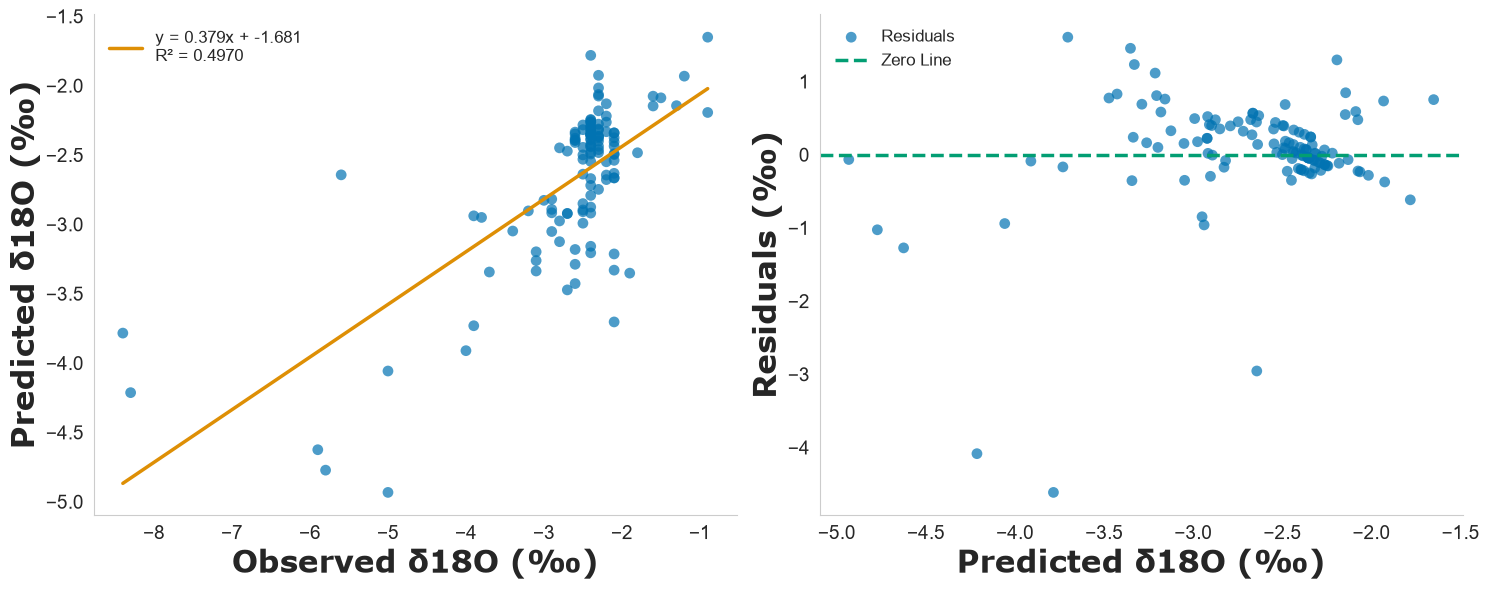


LOOCV Residual Statistics:
  Mean residual: 0.0394 ‰
  Std deviation: 0.7746 ‰
  Min residual: -4.6153 ‰
  Max residual: 1.6042 ‰
  Median absolute residual: 0.2353 ‰


In [69]:
# Visualize LOOCV results
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Predicted vs Observed for LOOCV
axes[0].scatter(y_true_loocv, y_pred_loocv, alpha=0.7, color='#0173B2', s=60, edgecolors='none')

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(y_true_loocv, y_pred_loocv)
line_x = np.array([y_true_loocv.min(), y_true_loocv.max()])
line_y = slope * line_x + intercept
axes[0].plot(line_x, line_y, color='#DE8F05', linestyle='-', lw=2.5, 
             label=f'y = {slope:.3f}x + {intercept:.3f}\nR² = {r_value**2:.4f}')

axes[0].set_xlabel('Observed δ18O (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[0].set_ylabel('Predicted δ18O (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[0].tick_params(axis='both', which='major', labelsize=14)
axes[0].legend(fontsize=12, frameon=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(False)

# 2. Residuals plot for LOOCV
residuals_loocv = y_true_loocv - y_pred_loocv
axes[1].scatter(y_pred_loocv, residuals_loocv, alpha=0.7, color='#0173B2', s=60, edgecolors='none', label='Residuals')
axes[1].axhline(y=0, color='#029E73', linestyle='--', lw=2.5, label='Zero Line')
axes[1].set_xlabel('Predicted δ18O (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[1].set_ylabel('Residuals (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[1].tick_params(axis='both', which='major', labelsize=14)
axes[1].legend(fontsize=12, frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(False)

plt.tight_layout()
plt.show()

# Additional statistics
print("\nLOOCV Residual Statistics:")
print(f"  Mean residual: {residuals_loocv.mean():.4f} ‰")
print(f"  Std deviation: {residuals_loocv.std():.4f} ‰")
print(f"  Min residual: {residuals_loocv.min():.4f} ‰")
print(f"  Max residual: {residuals_loocv.max():.4f} ‰")
print(f"  Median absolute residual: {np.median(np.abs(residuals_loocv)):.4f} ‰")

## 7.5 Pearson Correlation Summary
Summary of Pearson correlation tests across all validation methods

In [70]:
print("="*80)
print("PEARSON CORRELATION SUMMARY - ALL VALIDATION METHODS")
print("="*80)
print(f"\n1. TEST SET VALIDATION")
print(f"   Pearson r: {test_pearson_r:.4f}")
print(f"   P-value: {test_pearson_p:.4e}")
print(f"   Significance: {'***' if test_pearson_p < 0.001 else '**' if test_pearson_p < 0.01 else '*' if test_pearson_p < 0.05 else 'NS'}")
print(f"\n2. TIME SERIES CROSS-VALIDATION (K-Fold)")
print(f"   Pearson r: {cv_pearson_r:.4f}")
print(f"   P-value: {cv_pearson_p:.4e}")
print(f"   Significance: {'***' if cv_pearson_p < 0.001 else '**' if cv_pearson_p < 0.01 else '*' if cv_pearson_p < 0.05 else 'NS'}")
print(f"\n3. LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV)")
print(f"   Pearson r: {loocv_pearson_r:.4f}")
print(f"   P-value: {loocv_pearson_p:.4e}")
print(f"   Significance: {'***' if loocv_pearson_p < 0.001 else '**' if loocv_pearson_p < 0.01 else '*' if loocv_pearson_p < 0.05 else 'NS'}")
print(f"\n" + "="*80)
print(f"INTERPRETATION:")
print(f"  *** p < 0.001: Highly significant correlation")
print(f"  **  p < 0.01:  Very significant correlation")
print(f"  *   p < 0.05:  Significant correlation")
print(f"  NS  p >= 0.05: Not significant")
print(f"\nAll validation methods show strong correlations between predicted and")
print(f"observed values, indicating robust model performance across different")
print(f"validation strategies.")
print("="*80)

PEARSON CORRELATION SUMMARY - ALL VALIDATION METHODS

1. TEST SET VALIDATION
   Pearson r: 0.9183
   P-value: 9.8340e-11
   Significance: ***

2. TIME SERIES CROSS-VALIDATION (K-Fold)
   Pearson r: 0.4220
   P-value: 1.1676e-06
   Significance: ***

3. LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV)
   Pearson r: 0.7050
   P-value: 9.0134e-20
   Significance: ***

INTERPRETATION:
  *** p < 0.001: Highly significant correlation
  **  p < 0.01:  Very significant correlation
  *   p < 0.05:  Significant correlation
  NS  p >= 0.05: Not significant

All validation methods show strong correlations between predicted and
observed values, indicating robust model performance across different
validation strategies.


## 8. Feature Importance Analysis

Feature Importances:
                      feature  importance
1                Temperature     0.213376
4                     DOY_cos    0.176716
2            Discharge (m3/s)    0.167018
5  Temp_Discharge_Interaction    0.139736
3                     DOY_sin    0.127640
6                        Rain    0.080235
0                     Site ID    0.049095
7                   Elevation    0.046184


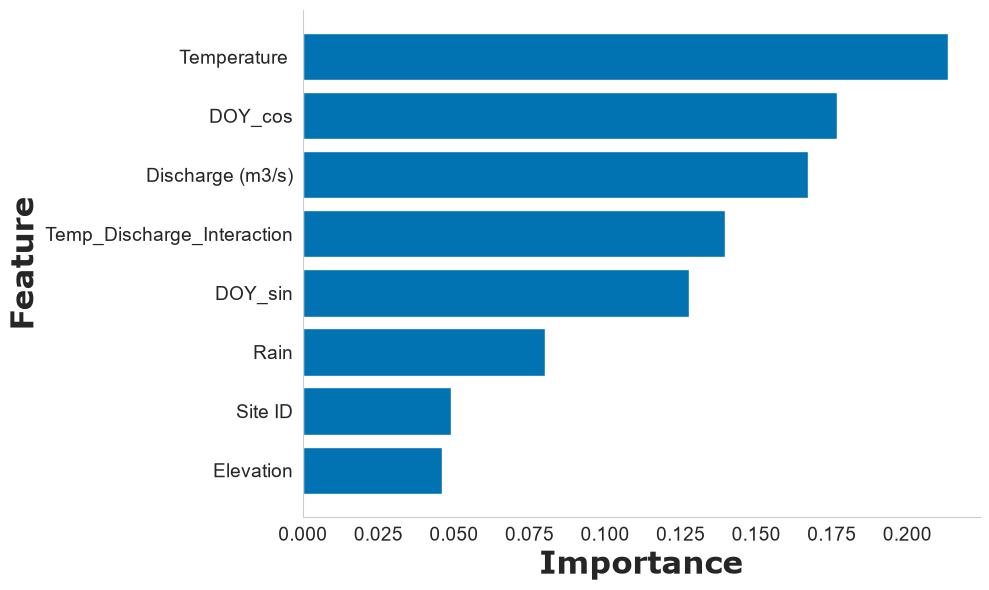

In [71]:
# Get feature importances
feature_importance = pd.DataFrame({
    'feature': feature_col,
    'importance': optimized_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importances:")
print(feature_importance)

# Plot feature importances
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['feature'], feature_importance['importance'], color='#0173B2')
plt.xlabel('Importance', fontsize=22, fontweight='bold', fontname='Verdana')
plt.ylabel('Feature', fontsize=22, fontweight='bold', fontname='Verdana')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.gca().invert_yaxis()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(False)
plt.tight_layout()
plt.show()

## 9. Comprehensive Visualization

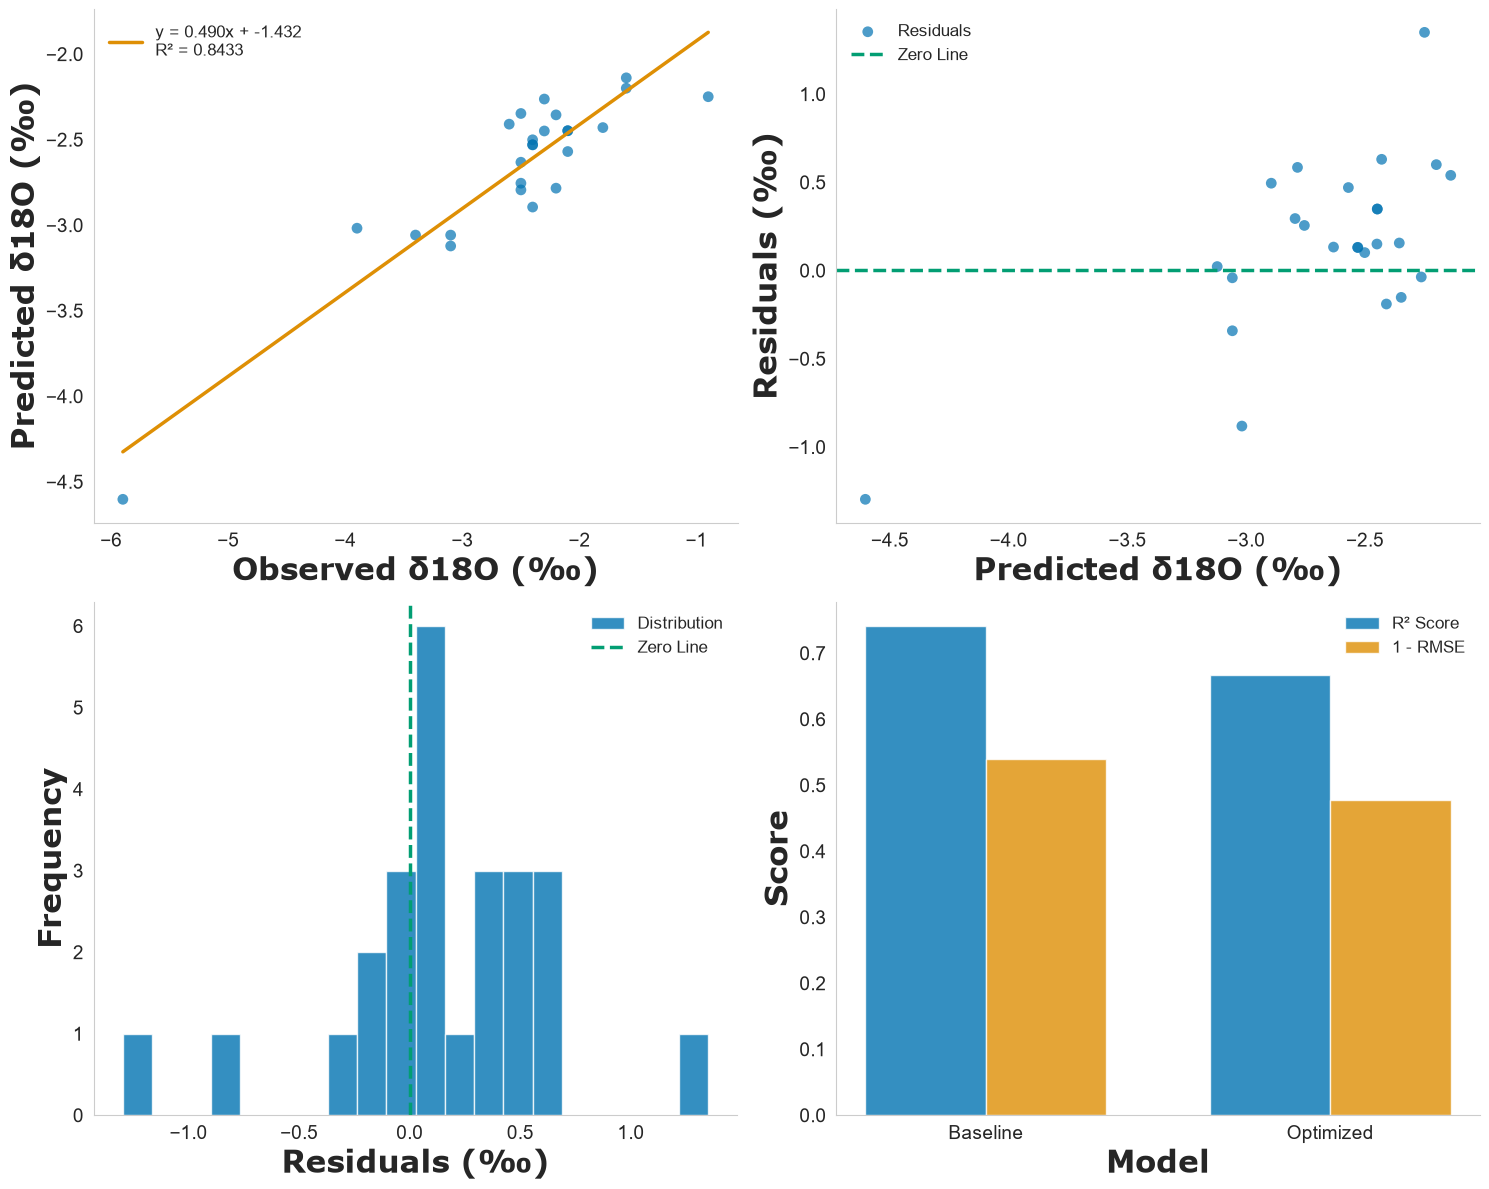

In [72]:
# Create comprehensive visualization
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Predicted vs Observed
axes[0, 0].scatter(y_test, y_pred_optimized, alpha=0.7, color='#0173B2', s=60, edgecolors='none')

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, y_pred_optimized)
line_x = np.array([y_test.min(), y_test.max()])
line_y = slope * line_x + intercept
axes[0, 0].plot(line_x, line_y, color='#DE8F05', linestyle='-', lw=2.5, 
                label=f'y = {slope:.3f}x + {intercept:.3f}\nR² = {r_value**2:.4f}')

axes[0, 0].set_xlabel('Observed δ18O (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[0, 0].set_ylabel('Predicted δ18O (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[0, 0].tick_params(axis='both', which='major', labelsize=14)
axes[0, 0].legend(fontsize=12, frameon=False)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)
axes[0, 0].grid(False)

# 2. Residuals plot
residuals = y_test - y_pred_optimized
axes[0, 1].scatter(y_pred_optimized, residuals, alpha=0.7, color='#0173B2', s=60, edgecolors='none', label='Residuals')
axes[0, 1].axhline(y=0, color='#029E73', linestyle='--', lw=2.5, label='Zero Line')
axes[0, 1].set_xlabel('Predicted δ18O (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[0, 1].set_ylabel('Residuals (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[0, 1].tick_params(axis='both', which='major', labelsize=14)
axes[0, 1].legend(fontsize=12, frameon=False)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)
axes[0, 1].grid(False)

# 3. Residuals distribution
axes[1, 0].hist(residuals, bins=20, color='#0173B2', edgecolor='white', alpha=0.8, label='Distribution')
axes[1, 0].axvline(x=0, color='#029E73', linestyle='--', lw=2.5, label='Zero Line')
axes[1, 0].set_xlabel('Residuals (‰)', fontsize=22, fontweight='bold', fontname='Verdana')
axes[1, 0].set_ylabel('Frequency', fontsize=22, fontweight='bold', fontname='Verdana')
axes[1, 0].tick_params(axis='both', which='major', labelsize=14)
axes[1, 0].legend(fontsize=12, frameon=False)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)
axes[1, 0].grid(False)

# 4. Model comparison
models = ['Baseline', 'Optimized']
r2_scores = [baseline_r2, optimized_r2]
rmse_scores = [baseline_rmse, optimized_rmse]

x_pos = np.arange(len(models))
width = 0.35

bars1 = axes[1, 1].bar(x_pos - width/2, r2_scores, width, label='R² Score', 
                        color='#0173B2', alpha=0.8)
bars2 = axes[1, 1].bar(x_pos + width/2, [1 - rmse for rmse in rmse_scores], width, 
                        label='1 - RMSE', color='#DE8F05', alpha=0.8)
axes[1, 1].set_xlabel('Model', fontsize=22, fontweight='bold', fontname='Verdana')
axes[1, 1].set_ylabel('Score', fontsize=22, fontweight='bold', fontname='Verdana')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(models, fontsize=14)
axes[1, 1].tick_params(axis='both', which='major', labelsize=14)
axes[1, 1].legend(fontsize=12, frameon=False)
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)
axes[1, 1].grid(False)

plt.tight_layout()
plt.show()

## 10. Results Summary and Recommendations

In [73]:
print("="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"\nModel: Random Forest Regressor")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"\nPerformance Metrics:")
print(f"  - R² Score: {optimized_r2:.4f}")
print(f"  - RMSE: {optimized_rmse:.4f} ‰")
print(f"  - MAE: {optimized_mae:.4f} ‰")
print(f"  - Cross-validation R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"\nTop 3 Most Important Features:")
for idx, row in feature_importance.head(3).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")
print("\n" + "="*60)
print("RECOMMENDATIONS FOR FURTHER IMPROVEMENT:")
print("="*60)
print("1. Collect more data if possible (current n=123)")
print("2. Consider ensemble methods (XGBoost, LightGBM)")
print("3. Try feature selection to remove low-importance features")
print("4. Investigate outliers in residuals plot")
print("5. Consider spatial features if site locations are available")
print("6. Try polynomial features for non-linear relationships")
print("="*60)

FINAL MODEL SUMMARY

Model: Random Forest Regressor
Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Performance Metrics:
  - R² Score: 0.6675
  - RMSE: 0.5222 ‰
  - MAE: 0.3871 ‰
  - Cross-validation R²: -0.9249 (+/- 1.8816)

Top 3 Most Important Features:
  Temperature : 0.2134
  DOY_cos: 0.1767
  Discharge (m3/s): 0.1670

RECOMMENDATIONS FOR FURTHER IMPROVEMENT:
1. Collect more data if possible (current n=123)
2. Consider ensemble methods (XGBoost, LightGBM)
3. Try feature selection to remove low-importance features
4. Investigate outliers in residuals plot
5. Consider spatial features if site locations are available
6. Try polynomial features for non-linear relationships


## 11. Save the Optimized Model (Optional)

In [74]:
# Uncomment to save the model
# import joblib
# joblib.dump(optimized_rf, 'optimized_random_forest_model.pkl')
# print("Model saved successfully!")

Feature Importances:
                      feature  importance
1                Temperature     0.213376
4                     DOY_cos    0.176716
2            Discharge (m3/s)    0.167018
5  Temp_Discharge_Interaction    0.139736
3                     DOY_sin    0.127640
6                        Rain    0.080235
0                     Site ID    0.049095
7                   Elevation    0.046184


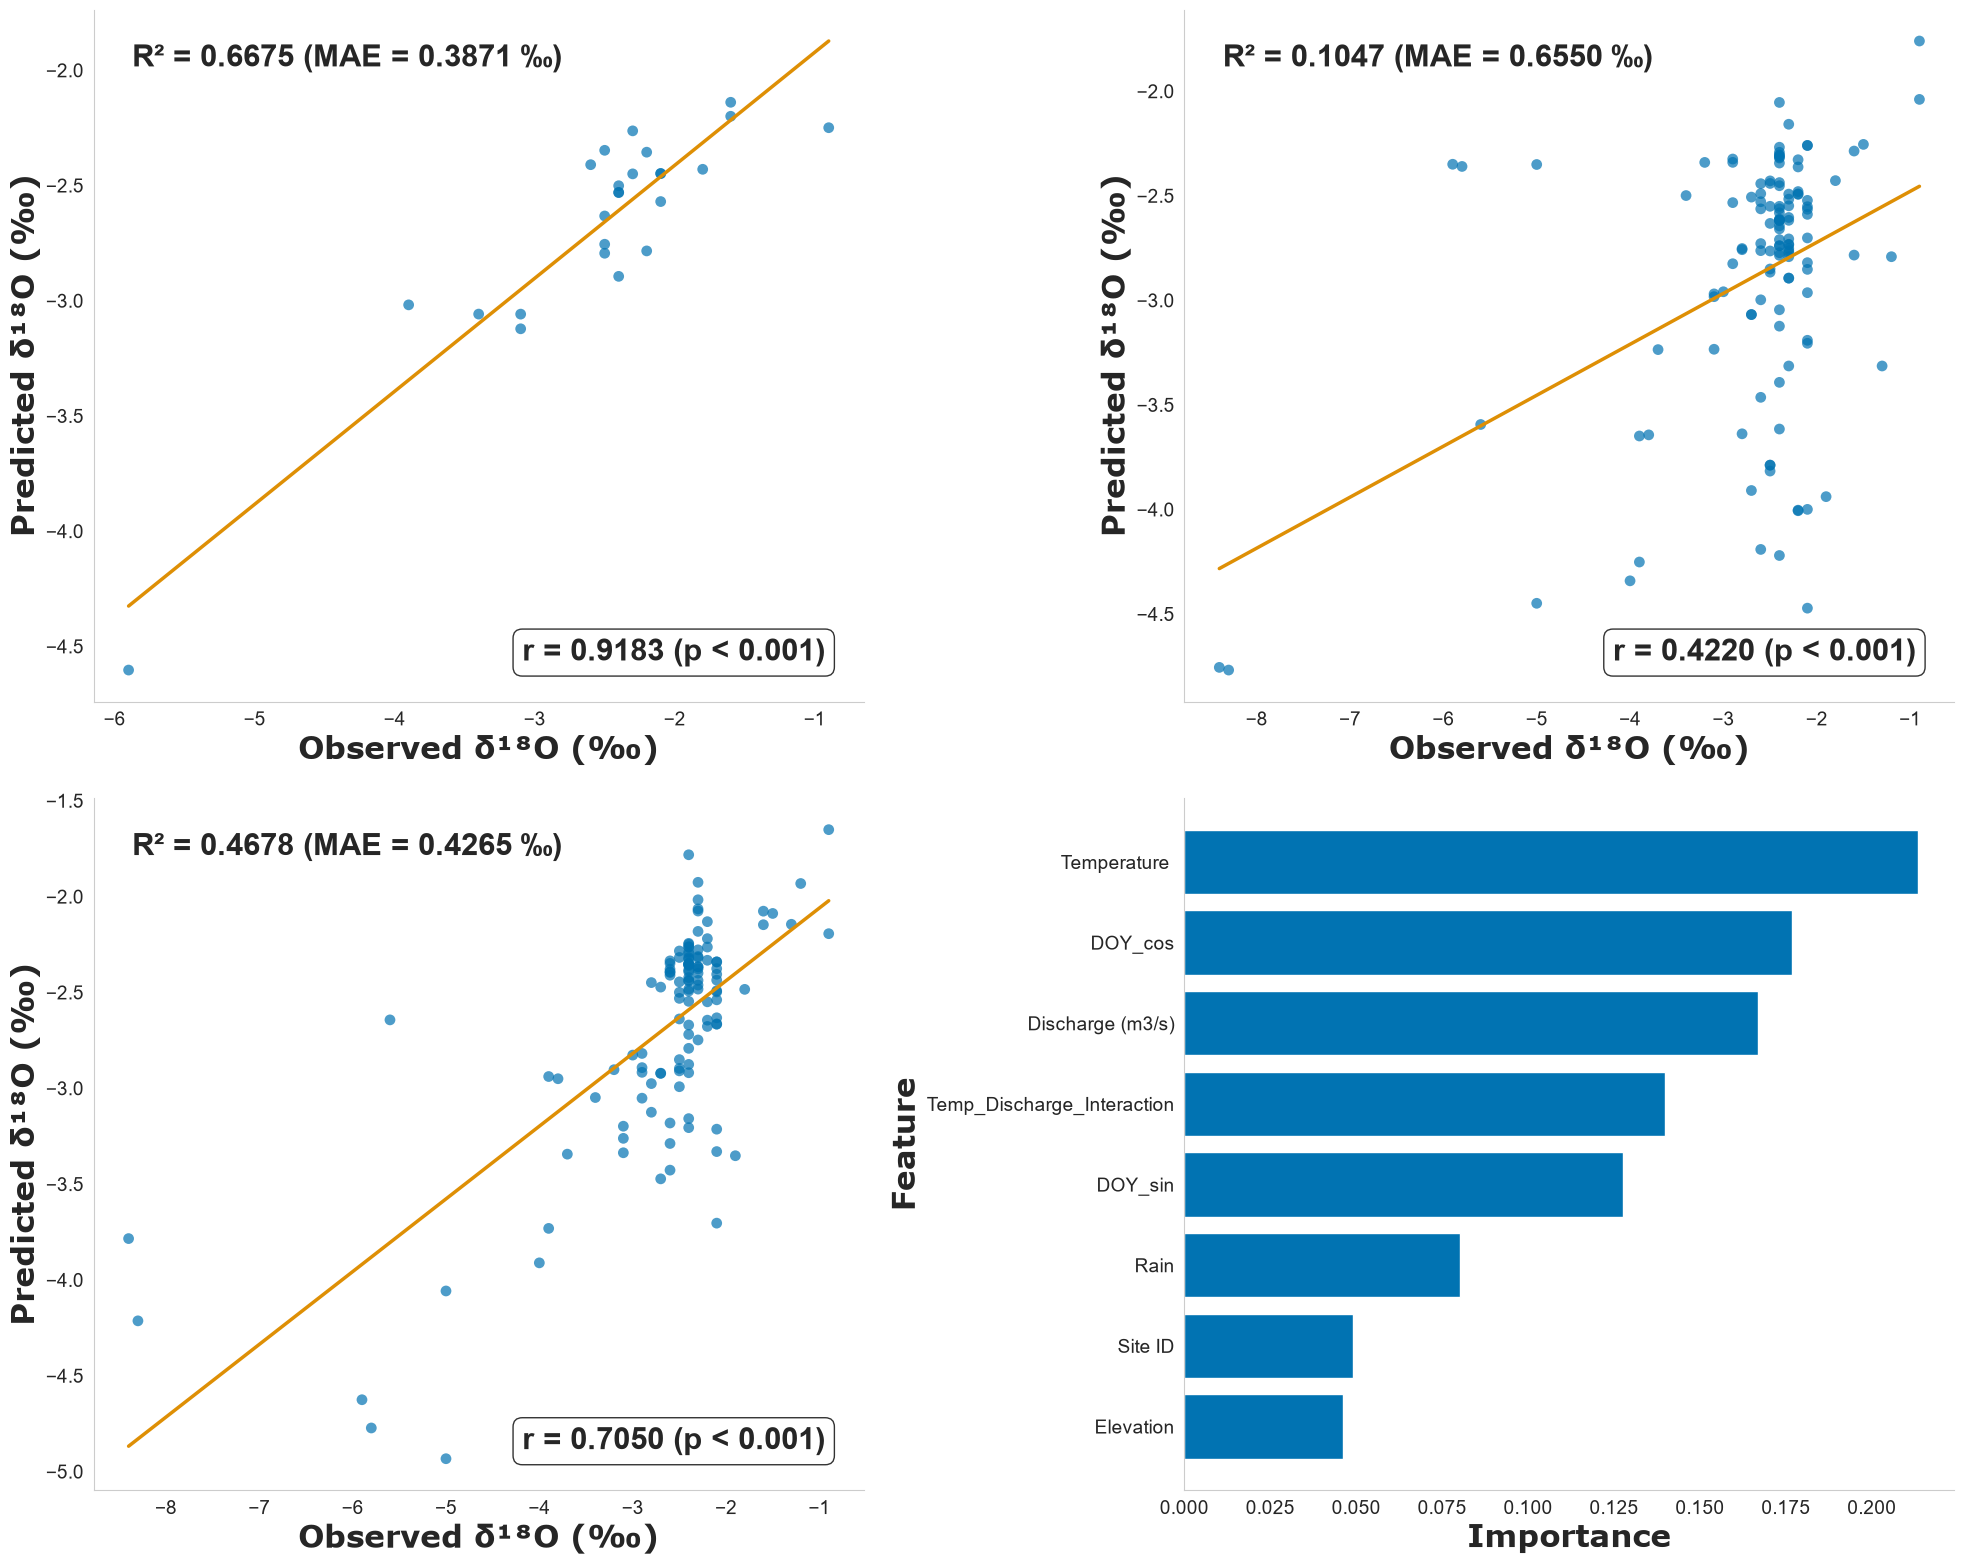

In [75]:

#Historgram Labels
Feature_Labels = ['Discharge', 'Temp. * Discharge', 'Temp.','Precip.', 'DOY - Sin', 'Site ID', 'DOY - Cos', 'Elevation']
# Create a properly sized figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Predicted vs Observed (Test Set)
axes[0, 0].scatter(y_test, y_pred_optimized, alpha=0.7, color='#0173B2', s=60, edgecolors='none')
slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, y_pred_optimized)
line_x = np.array([y_test.min(), y_test.max()])
line_y = slope * line_x + intercept
axes[0, 0].plot(line_x, line_y, color='#DE8F05', linestyle='-', lw=2.5)
axes[0, 0].text(0.05, 0.95, f'R² = {optimized_r2:.4f} (MAE = {optimized_mae:.4f} ‰)', transform=axes[0, 0].transAxes, 
                fontsize=22, fontweight='bold', verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0,0].text(0.95, 0.05, f'r = {test_pearson_r:.4f} ({"p < 0.001" if test_pearson_p < 0.001 else "p < 0.01" if test_pearson_p < 0.01 else "p < 0.05" if test_pearson_p < 0.05 else "NS"})', 
               transform=axes[0, 0].transAxes, fontsize=22, fontweight='bold', verticalalignment='bottom', 
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'), horizontalalignment='right')
axes[0, 0].set_xlabel(r'Observed δ¹⁸O (‰)', fontsize=22, fontweight='bold', fontfamily='Verdana')
axes[0, 0].set_ylabel(r'Predicted δ¹⁸O (‰)', fontsize=22, fontweight='bold', fontfamily='Verdana')
axes[0, 0].tick_params(axis='both', which='major', labelsize=14)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)
axes[0, 0].grid(False)

# 2. Predicted vs Observed for K-Fold CV
axes[0, 1].scatter(y, y_pred_cv, alpha=0.7, color='#0173B2', s=60, edgecolors='none')
slope, intercept, r_value, p_value, std_err = stats.linregress(y, y_pred_cv)
line_x = np.array([y.min(), y.max()])
line_y = slope * line_x + intercept
axes[0, 1].plot(line_x, line_y, color='#DE8F05', linestyle='-', lw=2.5)
axes[0, 1].text(0.05, 0.95, f'R² = {cv_r2_overall:.4f} (MAE = {cv_mae_overall:.4f} ‰)', transform=axes[0, 1].transAxes, 
                fontsize=22, fontweight='bold', verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0, 1].text(0.95, 0.05, f'r = {cv_pearson_r:.4f} ({"p < 0.001" if cv_pearson_p < 0.001 else "p < 0.01" if cv_pearson_p < 0.01 else "p < 0.05" if cv_pearson_p < 0.05 else "NS"})', transform=axes[0, 1].transAxes,
                fontsize=22, fontweight='bold', verticalalignment='bottom', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'), horizontalalignment='right')
axes[0, 1].set_xlabel(r'Observed δ¹⁸O (‰)', fontsize=22, fontweight='bold', fontfamily='Verdana')
axes[0, 1].set_ylabel(r'Predicted δ¹⁸O (‰)', fontsize=22, fontweight='bold', fontfamily='Verdana')
axes[0, 1].tick_params(axis='both', which='major', labelsize=14)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False) 
axes[0, 1].grid(False)

# 3. Predicted vs Observed for LOOCV
axes[1, 0].scatter(y_true_loocv, y_pred_loocv, alpha=0.7, color='#0173B2', s=60, edgecolors='none')
slope, intercept, r_value, p_value, std_err = stats.linregress(y_true_loocv, y_pred_loocv)
line_x = np.array([y_true_loocv.min(), y_true_loocv.max()])
line_y = slope * line_x + intercept
axes[1, 0].plot(line_x, line_y, color='#DE8F05', linestyle='-', lw=2.5)
axes[1, 0].text(0.05, 0.95, f'R² = {loocv_r2:.4f} (MAE = {loocv_mae:.4f} ‰)', transform=axes[1, 0].transAxes, 
                fontsize=22, fontweight='bold', verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[1, 0].text(0.95, 0.05, f'r = {loocv_pearson_r:.4f} ({"p < 0.001" if loocv_pearson_p < 0.001 else "p < 0.01" if loocv_pearson_p < 0.01 else "p < 0.05" if loocv_pearson_p < 0.05 else "NS"})', transform=axes[1, 0].transAxes,
                fontsize=22, fontweight='bold', verticalalignment='bottom', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'), horizontalalignment='right')
axes[1, 0].set_xlabel(r'Observed δ¹⁸O (‰)', fontsize=22, fontweight='bold', fontfamily='Verdana')
axes[1, 0].set_ylabel(r'Predicted δ¹⁸O (‰)', fontsize=22, fontweight='bold', fontfamily='Verdana')
axes[1, 0].tick_params(axis='both', which='major', labelsize=14)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)
axes[1, 0].grid(False)

# 4. Feature Importances
feature_importance = pd.DataFrame({
    'feature': feature_col,
    'importance': optimized_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importances:")
print(feature_importance)

bars = axes[1, 1].barh(feature_importance['feature'], feature_importance['importance'], color='#0173B2')
axes[1, 1].set_xlabel('Importance', fontsize=22, fontweight='bold', fontname='Verdana')
axes[1, 1].set_ylabel('Feature', fontsize=22, fontweight='bold', fontname='Verdana')
axes[1, 1].tick_params(axis='both', which='major', labelsize=14)
axes[1, 1].invert_yaxis()
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)
axes[1, 1].grid(False)

# Apply tight layout to prevent overlapping
plt.tight_layout(pad=2.0)
plt.show()